# Create a recommender system for romance readers

In [1]:
import sqlite3
import pandas as pd
import numpy as np

### Load data in
Using sqlite3 db

In [2]:
# open romance.db in sqlite3
conn = sqlite3.connect("byGenre/romance.db")
cursor = conn.cursor()

In [3]:
# key reinforcement
cursor.execute("PRAGMA foreign_keys = ON;")

# speed boost
cursor.execute("PRAGMA journal_mode = WAL;")
cursor.execute("PRAGMA synchronous = OFF;")
cursor.execute("PRAGMA temp_store = FILE;")
cursor.execute("PRAGMA cache_size = -200000;")  # ~200MB RAM

In [4]:
# check ratings table
ratings = pd.read_sql_query(
    "SELECT * FROM ratings",
    conn
)
ratings.head()

,review_id,user_id,book_id,rating
0,d0aa055c0b0a5b0c4f13f9d358d51cd9,8842281e1d1347389f2ab93d60773d4d,18135,4.0
1,11beb5d3be4ebe9983ffa224b968dd17,72fb0d0087d28c832f15776b0d936598,1885,5.0
2,303e3bb8890afde2b3849e9c1ebeaafe,ab2923b738ea3082f5f3efcbbfacb218,47401,4.0
3,fa6ede0afb0a5e0b4d7b78855f81d8ed,ab2923b738ea3082f5f3efcbbfacb218,227443,3.0
4,d6d8cb411ba38957e6c9f0fd80e7617c,ab2923b738ea3082f5f3efcbbfacb218,6185,3.0


## Filter dataset on active users and popular books

The dataset is huge, so to make training iterations tractable on local I filter on:
1. users with >= 15 books rated
2. books with >= 5 total ratings

In [5]:
# compute rating counts per user
user_counts = ratings['user_id'].value_counts()

print(user_counts.describe())

count    549278.000000
mean         29.551304
std         106.984293
min           1.000000
25%           2.000000
50%           5.000000
75%          15.000000
max        6390.000000
Name: count, dtype: float64


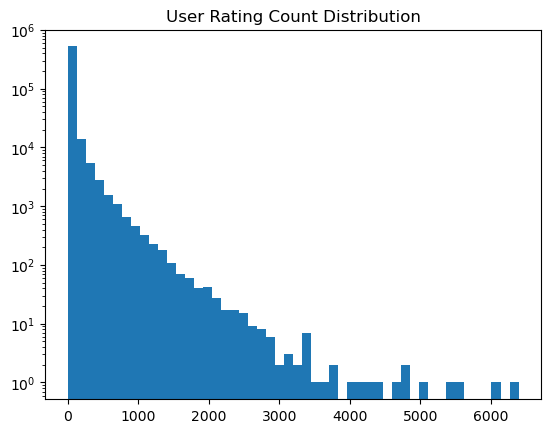

In [8]:
import matplotlib.pyplot as plt

plt.hist(user_counts, bins=50)
plt.yscale("log")
plt.title("User Rating Count Distribution")
plt.show()

In [6]:
# only keep users with >= 15 ratings to manage data size
MIN_RATINGS = 15 #75%

active_users = user_counts[user_counts >= MIN_RATINGS].index

ratings_active = ratings[ratings['user_id'].isin(active_users)]

print("Original rows:", len(ratings))
print("Filtered rows:", len(ratings_active))
print("Active users:", ratings_active['user_id'].nunique())

Original rows: 16231881
Filtered rows: 14496446
Active users: 142093


In [7]:
# compute rating counts per book
book_counts = ratings_active['book_id'].value_counts()

book_counts.describe()

count    283631.000000
mean         51.110231
std         349.082097
min           1.000000
25%           3.000000
50%           8.000000
75%          24.000000
max       46027.000000
Name: count, dtype: float64

In [8]:
# only keep books with >= 5 ratings
MIN_COUNTS = 5 #between 25 - 50%

popular_books = book_counts[book_counts >= MIN_COUNTS].index

ratings_filtered = ratings_active[
    ratings_active['book_id'].isin(popular_books)
]


print("Original rows:", len(ratings_active))
print("Filtered rows:", len(ratings_filtered))
print("Popular Books:", ratings_filtered['book_id'].nunique())

Original rows: 14496446
Filtered rows: 14273971
Popular Books: 181998


## Prep data for ALS

The goal is to use `implicit` library's implementation of ALS and other recommender algorithms. These are based on implicit collaborative filtering, meaning that any interactions recorded indicate positive feedback. Thus we filter out negative ratings (1-2) as these can be misinterpreted by the models, and scale the other values to preserve weights of the ratings. 

In [9]:
# filter negative ratings (1 & 2)
# scale ratings to confidence in positive interaction for ALS
ratings_pos = ratings_filtered[ratings_filtered['rating'] >= 3]
ratings_pos['confidence'] = ratings_pos['rating'] - 2  # maps 3→1, 4→2, 5→3

print("Original rows:", len(ratings_filtered))
print("Filtered rows:", len(ratings_pos))

Original rows: 14273971
Filtered rows: 13254477


/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/807650794.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_pos['confidence'] = ratings_pos['rating'] - 2  # maps 3→1, 4→2, 5→3


In [44]:
# encode user and book ids to integers for conversion to csr
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

ratings_pos['user_idx'] = user_encoder.fit_transform(ratings_pos['user_id'])
ratings_pos['book_idx'] = book_encoder.fit_transform(ratings_pos['book_id'])

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2913408694.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_pos['user_idx'] = user_encoder.fit_transform(ratings_pos['user_id'])
/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2913408694.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_pos['book_idx'] = book_encoder.fit_transform(ratings_pos['book_id'])


In [45]:
# generate sparse matrix with confidence scores as values
from scipy.sparse import csr_matrix

n_users = ratings_pos['user_idx'].nunique()
n_books = ratings_pos['book_idx'].nunique()

user_item_matrix = csr_matrix(
    (
        ratings_pos['confidence'], # use scaled confidence instead of rating
        (ratings_pos['user_idx'], ratings_pos['book_idx'])
    ),
    shape=(n_users, n_books)
)

In [46]:
print(user_item_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13254477 stored elements and shape (142078, 181983)>
  Coords	Values
  (0, 30308)	3.0
  (0, 122761)	3.0
  (0, 122763)	2.0
  (0, 122764)	2.0
  (0, 122765)	2.0
  (0, 122766)	2.0
  (0, 122767)	2.0
  (0, 122768)	2.0
  (0, 122769)	2.0
  (0, 122770)	2.0
  (0, 122771)	2.0
  (0, 122772)	2.0
  (0, 122773)	2.0
  (0, 122774)	2.0
  (0, 122775)	2.0
  (0, 122776)	2.0
  (0, 122777)	2.0
  (0, 122778)	2.0
  (0, 122780)	2.0
  (0, 122781)	1.0
  (0, 154514)	2.0
  (1, 1453)	3.0
  (1, 3874)	3.0
  (1, 4602)	2.0
  (1, 6181)	3.0
  :	:
  (142076, 180237)	2.0
  (142076, 180807)	1.0
  (142076, 180936)	3.0
  (142076, 180978)	2.0
  (142076, 181336)	2.0
  (142076, 181605)	3.0
  (142077, 25903)	3.0
  (142077, 48478)	2.0
  (142077, 49530)	2.0
  (142077, 52003)	2.0
  (142077, 56882)	1.0
  (142077, 71181)	3.0
  (142077, 80278)	1.0
  (142077, 95358)	2.0
  (142077, 99991)	3.0
  (142077, 104273)	3.0
  (142077, 116695)	3.0
  (142077, 123289)	3.0
  (142077, 148389

## Model Training/Testing

I do two different train/test splits:
1. 80/20 train/test split per user (trained on 80% of their interactions)
2. Leave-k-out (k = 3 = 0.2*15) since 15 is the minimum ratings per user

(2) is harder because a smaller amount of books in the holdout set, no telling if they are closely linked to the training books.

### Option 1: 80/20 interactions split per user

In [13]:
# Option 1: 80/20 interactions split per user
# generate train-test split of csr matrix
from scipy.sparse import lil_matrix

def train_test_split_per_user(csr, test_frac=0.2, random_state=42):
    """
    Hold out a fraction of each user's interactions as the test set.
    Returns two CSR matrices of the same shape.
    """
    rng = np.random.default_rng(random_state)
    
    train = lil_matrix(csr.shape) #ListofLists sparse matrix
    test = lil_matrix(csr.shape)
    
    csr = csr.tocsr()
    
    for user_id in range(csr.shape[0]):
        # Get all items this user interacted with
        item_indices = csr[user_id].indices
        ratings = csr[user_id].data
        
        if len(item_indices) == 0:
            continue
            
        # Need at least 2 interactions to split
        n_test = max(1, int(len(item_indices) * test_frac))
        if len(item_indices) - n_test < 1:
            # Not enough interactions — put everything in train
            train[user_id, item_indices] = ratings
            continue
        
        # Randomly select test indices
        test_mask = rng.choice(len(item_indices), size=n_test, replace=False)
        train_mask = np.setdiff1d(np.arange(len(item_indices)), test_mask)
        
        train[user_id, item_indices[train_mask]] = ratings[train_mask]
        test[user_id, item_indices[test_mask]] = ratings[test_mask]
    
    return train.tocsr(), test.tocsr()


train, test = train_test_split_per_user(user_item_matrix, test_frac=0.2)

In [14]:
train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10659768 stored elements and shape (142078, 181983)>

In [15]:
test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2594709 stored elements and shape (142078, 181983)>

In [16]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(train)

/opt/anaconda3/envs/goodreads-env/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

Internal evaluation functions in `implicit` were not working, so I defined my own

In [85]:
# import numpy as np

# # precision@K -- what fraction of the recommended top K were found in each user's test books?
# def precision_at_k(model, train, test, K=10):
#     precisions = []
    
#     for user_id in range(train.shape[0]):
#         test_items = test[user_id].indices
#         if len(test_items) == 0:
#             continue
        
#         recs = model.recommend(
#             user_id, 
#             train[user_id],
#             N=K, 
#             filter_already_liked_items=True
#         )
#         # implicit 0.7.x returns (item_ids, scores) as two arrays
#         rec_items = recs[0]
        
#         n_relevant = len(np.intersect1d(rec_items, test_items))
#         precisions.append(n_relevant / K)
    
#     return np.mean(precisions)


# # recall@K -- what fraction of each user's test books were found in top K recommended?
# def recall_at_k(model, train, test, K=10):
#     recalls = []
#     for user_id in range(train.shape[0]):
#         test_items = test[user_id].indices
#         if len(test_items) == 0:
#             continue
#         recs = model.recommend(user_id, train[user_id], N=K, filter_already_liked_items=True)
#         rec_items = recs[0]
#         n_relevant = len(np.intersect1d(rec_items, test_items))
#         recalls.append(n_relevant / len(test_items))
#     return np.mean(recalls)


# # Normalized Discounted Cumulative Gain (NDCG):
# # Discounted CG (DCG) - adds a position penalty using a log discount (#1 = 1.0, #10 = 0.29)
# # Ideal DCG - what would be if all relevant items ranked first
# # NDCG = DCG / IDCG
# def ndcg_at_k(model, train, test, K=10):
#     ndcgs = []
    
#     for user_id in range(train.shape[0]):
#         test_items = set(test[user_id].indices)
#         if len(test_items) == 0:
#             continue
        
#         recs = model.recommend(
#             user_id,
#             train[user_id],
#             N=K,
#             filter_already_liked_items=True
#         )
#         rec_items = recs[0]
        
#         # Compute DCG
#         dcg = sum(
#             1 / np.log2(rank + 2)
#             for rank, item in enumerate(rec_items)
#             if item in test_items
#         )
#         # Compute ideal DCG
#         ideal_hits = min(len(test_items), K)
#         idcg = sum(1 / np.log2(rank + 2) for rank in range(ideal_hits))
        
#         ndcgs.append(dcg / idcg if idcg > 0 else 0)
    
#     return np.mean(ndcgs)


In [16]:
import numpy as np
from joblib import Parallel, delayed

def _evaluate_user(user_id, model, train, test, K):
    """Compute precision, recall and NDCG for a single user."""
    test_items = test[user_id].indices
    if len(test_items) == 0:
        return None
    
    recs = model.recommend(
        user_id,
        train[user_id],
        N=K,
        filter_already_liked_items=True
    )
    rec_items = recs[0]
    test_items_set = set(test_items)
    
    # Precision & Recall
    n_relevant = len(np.intersect1d(rec_items, test_items))
    precision = n_relevant / K
    recall = n_relevant / len(test_items)
    
    # NDCG
    dcg = sum(
        1 / np.log2(rank + 2)
        for rank, item in enumerate(rec_items)
        if item in test_items_set
    )
    ideal_hits = min(len(test_items), K)
    idcg = sum(1 / np.log2(rank + 2) for rank in range(ideal_hits))
    ndcg = dcg / idcg if idcg > 0 else 0
    
    return precision, recall, ndcg


def evaluate_model(model, train, test, K=10, n_jobs=-1):
    """
    Evaluate model across all users in parallel.
    n_jobs=-1 uses all available cores.
    """
    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(_evaluate_user)(user_id, model, train, test, K)
        for user_id in range(train.shape[0])
    )
    
    # Filter out users with no test interactions
    results = [r for r in results if r is not None]
    precisions, recalls, ndcgs = zip(*results)
    
    return {
        f"precision@{K}": np.mean(precisions),
        f"recall@{K}":    np.mean(recalls),
        f"ndcg@{K}":      np.mean(ndcgs),
    }



In [18]:
# p_at_k = precision_at_k(model, train, test, K=10)
# ndcg = ndcg_at_k(model, train, test, K=10)
# print(f"Precision@10: {p_at_k:.4f}")
# print(f"NDCG@10:      {ndcg:.4f}")

metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)
print(metrics)

precision@10
recall@10
ndcg@10


In [20]:
print(metrics)

{'precision@10': np.float64(0.1792644212156407), 'recall@10': np.float64(0.19450839170858142), 'ndcg@10': np.float64(0.2693991065338656)}


### Option 2: Leave-k-out

In [17]:
# Leave k out - k = 3 here.
from implicit.evaluation import leave_k_out_split

trainK, testK = leave_k_out_split(user_item_matrix, K=3, random_state=42)

In [21]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(trainK)

  0%|          | 0/20 [00:00<?, ?it/s]

In [23]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.06183917601307557), 'recall@10': np.float64(0.20613058671025192), 'ndcg@10': np.float64(0.1763510477785371)}


## Try increasing factors and iterations 

### 80/20 Split

In [18]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(train)

/opt/anaconda3/envs/goodreads-env/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/50 [00:00<?, ?it/s]

In [19]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.20254742547425475), 'recall@10': np.float64(0.2121068170302732), 'ndcg@10': np.float64(0.29853882580141927)}


### Leave-k-out

In [25]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(trainK)

  0%|          | 0/50 [00:00<?, ?it/s]

In [94]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.07040452572845629), 'recall@10': np.float64(0.23468175242818767), 'ndcg@10': np.float64(0.20063686394981795)}


## Bayesian Personalized Ranking

Start small with 50 factors and 20 iterations

### 80/20

In [20]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(train)

  0%|          | 0/20 [00:00<?, ?it/s]

In [21]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.07485939534720024), 'recall@10': np.float64(0.08715836550930486), 'ndcg@10': np.float64(0.11034397587162754)}


### Leave-k-out

In [22]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(trainK)

  0%|          | 0/20 [00:00<?, ?it/s]

In [23]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.03209998309192357), 'recall@10': np.float64(0.10699994363974524), 'ndcg@10': np.float64(0.08660198240773988)}


## Try increasing factors and iterations

### 80/20

In [24]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(train)

  0%|          | 0/50 [00:00<?, ?it/s]

In [25]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.08425368669271108), 'recall@10': np.float64(0.1077256574945524), 'ndcg@10': np.float64(0.1298913939436684)}


### Leave-k-out

In [26]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(trainK)

  0%|          | 0/50 [00:00<?, ?it/s]

In [27]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.03783745702530575), 'recall@10': np.float64(0.1261248567510192), 'ndcg@10': np.float64(0.10313280182045284)}


# Incorporating Book-Book Similarity Information

In [28]:
# Load from SQL
books = pd.read_sql_query(
    "SELECT * FROM similar_books",
    conn
)

books.head()

,book_id,similar_book_id
0,29074693,25515353
1,29074693,20483269
2,29074693,25650829
3,29074693,18913492
4,29074693,22578299


In [33]:
unique_books = ratings_pos['book_id'].unique()

mask = books['book_id'].isin(unique_books)
books_filtered = books[mask]

mask_2 = books_filtered['similar_book_id'].isin(unique_books)
books_filt = books_filtered[mask_2]

In [35]:
books_filt.shape

(1662509, 2)

In [37]:
books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2703192558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2703192558.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])


In [38]:
books_filt.head()

,book_id,similar_book_id,book_idx,sim_book_idx
0,29074693,25515353,124077,104512
2,29074693,25650829,124077,106061
3,29074693,18913492,124077,60510
4,29074693,22578299,124077,79764
5,29074693,25781561,124077,107607


In [52]:
n_books = len(book_encoder.classes_)

book_similarity_matrix = csr_matrix(
    (np.ones(len(books_filt), dtype=np.float32),
    (books_filt['book_idx'], books_filt['sim_book_idx'])),
    shape=(n_books, n_books)
)

book_similarity_matrix = book_similarity_matrix + book_similarity_matrix.T
book_similarity_matrix.data[book_similarity_matrix.data > 1] = 1

In [53]:
print(book_similarity_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 3059762 stored elements and shape (181983, 181983)>
  Coords	Values
  (1, 3850)	1.0
  (1, 6051)	1.0
  (1, 6523)	1.0
  (1, 7507)	1.0
  (1, 7508)	1.0
  (1, 11981)	1.0
  (1, 14293)	1.0
  (1, 30310)	1.0
  (1, 36365)	1.0
  (1, 36637)	1.0
  (1, 38092)	1.0
  (1, 48817)	1.0
  (1, 49223)	1.0
  (1, 55095)	1.0
  (1, 65321)	1.0
  (1, 74423)	1.0
  (1, 74687)	1.0
  (1, 77650)	1.0
  (1, 77812)	1.0
  (1, 82669)	1.0
  (1, 86093)	1.0
  (1, 95755)	1.0
  (1, 120807)	1.0
  (1, 136997)	1.0
  (1, 151494)	1.0
  :	:
  (181980, 170494)	1.0
  (181980, 170546)	1.0
  (181980, 170698)	1.0
  (181980, 171678)	1.0
  (181980, 173220)	1.0
  (181980, 178053)	1.0
  (181980, 178864)	1.0
  (181981, 7384)	1.0
  (181981, 19375)	1.0
  (181981, 22226)	1.0
  (181981, 29853)	1.0
  (181981, 31372)	1.0
  (181981, 64641)	1.0
  (181981, 71646)	1.0
  (181981, 156977)	1.0
  (181981, 158840)	1.0
  (181981, 176989)	1.0
  (181981, 180231)	1.0
  (181982, 3194)	1.0
  (181982, 184

In [60]:
print(train[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 17 stored elements and shape (1, 181983)>
  Coords	Values
  (0, 30308)	3.0
  (0, 122763)	2.0
  (0, 122764)	2.0
  (0, 122765)	2.0
  (0, 122766)	2.0
  (0, 122767)	2.0
  (0, 122768)	2.0
  (0, 122769)	2.0
  (0, 122771)	2.0
  (0, 122772)	2.0
  (0, 122773)	2.0
  (0, 122776)	2.0
  (0, 122777)	2.0
  (0, 122778)	2.0
  (0, 122780)	2.0
  (0, 122781)	1.0
  (0, 154514)	2.0


In [66]:
print((train + 0.1 * (train @ book_similarity_matrix)).tocsr()[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 85 stored elements and shape (1, 181983)>
  Coords	Values
  (0, 117544)	0.30000000000000004
  (0, 151520)	0.30000000000000004
  (0, 151524)	0.30000000000000004
  (0, 157099)	0.30000000000000004
  (0, 173853)	0.30000000000000004
  (0, 178082)	0.30000000000000004
  (0, 63)	0.2
  (0, 16059)	1.2000000000000002
  (0, 155408)	1.0
  (0, 155604)	0.4
  (0, 50466)	0.2
  (0, 62950)	0.2
  (0, 120471)	0.2
  (0, 152228)	0.4
  (0, 155610)	0.8
  (0, 51410)	0.2
  (0, 155603)	0.8
  (0, 158682)	0.2
  (0, 1715)	0.2
  (0, 1716)	0.2
  (0, 1718)	0.2
  (0, 8196)	0.2
  (0, 16060)	0.2
  (0, 155608)	0.2
  (0, 1064)	0.2
  :	:
  (0, 155609)	0.2
  (0, 164564)	0.2
  (0, 23475)	0.2
  (0, 152294)	0.2
  (0, 120369)	0.1
  (0, 120472)	0.1
  (0, 155607)	0.1
  (0, 84086)	0.2
  (0, 154514)	2.0
  (0, 122781)	1.0
  (0, 122780)	2.0
  (0, 122778)	2.0
  (0, 122777)	2.0
  (0, 122776)	2.0
  (0, 122773)	2.0
  (0, 122772)	2.0
  (0, 122771)	2.0
  (0, 122769)	2.0
  (0, 1227

In [67]:
alphas = [0, 0.01] # testing various levels of alpha 
results = []

for alpha in alphas:
    # Augment train
    augmented_train = (train + alpha * (train @ book_similarity_matrix)).tocsr()
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, test, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.00 | {'precision@10': np.float64(0.17872171189244368), 'recall@10': np.float64(0.19381266211193085), 'ndcg@10': np.float64(0.26873095558515514), 'alpha': 0}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.01 | {'precision@10': np.float64(0.09867243867243869), 'recall@10': np.float64(0.13590007809151983), 'ndcg@10': np.float64(0.16555782166969402), 'alpha': 0.01}


In [43]:
alphas = [0.1, 0.2, 0.3, 0.5] # testing various levels of alpha 
results = []

for alpha in alphas:
    # Augment train
    augmented_train = (train + alpha * (train @ book_similarity_matrix)).tocsr()
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, test, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

results_df = pd.DataFrame(results)
print(results_df)

  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.10 | {'precision@10': np.float64(0.06572554816457254), 'recall@10': np.float64(0.10146504580679576), 'ndcg@10': np.float64(0.11852834160068892), 'alpha': 0.1}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.20 | {'precision@10': np.float64(0.05058951888220182), 'recall@10': np.float64(0.08006421098377721), 'ndcg@10': np.float64(0.09326195040981235), 'alpha': 0.2}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.30 | {'precision@10': np.float64(0.04295076197515223), 'recall@10': np.float64(0.0687215899513075), 'ndcg@10': np.float64(0.07870054328729607), 'alpha': 0.3}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.50 | {'precision@10': np.float64(0.03429768063914405), 'recall@10': np.float64(0.055146059119777664), 'ndcg@10': np.float64(0.06023617601827491), 'alpha': 0.5}
   precision@10  recall@10   ndcg@10  alpha
0      0.065726   0.101465  0.118528    0.1
1      0.050590   0.080064  0.093262    0.2
2      0.042951   0.068722  0.078701    0.3
3      0.034298   0.055146  0.060236    0.5


In [ ]:
# book_similarity is a (n_items x n_items) sparse CSR matrix of BM25/cosine similarities
# alpha controls how much similarity signal to inject
alpha = 0.2

augmented_train = train + alpha * (train @ book_similarity_matrix)
augmented_train = augmented_train.tocsr()

# Train ALS on augmented matrix as normal
model = AlternatingLeastSquares(factors=50, iterations=20)
model.fit(augmented_train)

# Evaluate as normal
metrics = evaluate_model(model, augmented_train, test, K=10)

In [59]:
train = train.astype("float32")
test = test.astype("float32")

precision_at_k(model, train, test, K=10)

  0%|          | 0/141944 [00:00<?, ?it/s]

AttributeError: 'implicit.evaluation._memoryviewslice' object has no attribute 'dtype'

In [54]:
model.item_factors 

array([[-1.7858701e-03, -1.8712551e-04,  1.5109124e-04, ...,
         2.8127262e-03,  2.0821486e-03, -3.2865237e-03],
       [ 2.3299225e-03,  1.0463087e-02,  4.7679655e-03, ...,
         4.5406828e-03,  6.5882173e-03,  1.2763998e-02],
       [ 2.6499613e-03,  3.0595005e-05, -2.2297357e-03, ...,
         1.8959952e-04,  2.9298142e-03, -6.2295108e-04],
       ...,
       [-2.8960099e-03,  2.5646775e-03,  6.8213511e-04, ...,
         6.5055150e-03,  4.0083788e-03, -3.3141957e-03],
       [-2.7072823e-03,  2.6148430e-03,  1.8843908e-02, ...,
        -1.6360818e-03,  4.9299765e-03,  1.4703665e-03],
       [-2.1303656e-02,  5.3226450e-03,  6.0070134e-03, ...,
         3.7360247e-02,  1.9268895e-02, -1.3905366e-02]],
      shape=(181983, 50), dtype=float32)

In [55]:

from implicit.evaluation import precision_at_k

precision_at_k(model, train, test, K=10)

  0%|          | 0/142065 [00:00<?, ?it/s]

AttributeError: 'implicit.evaluation._memoryviewslice' object has no attribute 'dtype'

In [51]:
import implicit
import scipy
print(implicit.__version__)  # likely < 0.7.x
print(scipy.__version__)     # likely >= 1.14

0.7.2
1.15.2


In [60]:
from platform import python_version
print(python_version())

3.10.15


In [77]:
ndcg = ndcg_at_k(model, train, test, K=10)
print(f"NDCG@10:      {ndcg:.4f}")

NDCG@10:      0.2686


In [11]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

ratings_filtered['user_idx'] = user_encoder.fit_transform(ratings_filtered['user_id'])
ratings_filtered['book_idx'] = book_encoder.fit_transform(ratings_filtered['book_id'])

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_83701/1096096390.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_filtered['user_idx'] = user_encoder.fit_transform(ratings_filtered['user_id'])
/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_83701/1096096390.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_filtered['book_idx'] = book_encoder.fit_transform(ratings_filtered['book_id'])


In [12]:
ratings_filtered.head()

,review_id,user_id,book_id,rating,user_idx,book_idx
13,a0b5fc64eabe1fae3690a21ce1e65979,f8a89075dc6de14857561522e729f82c,25643846,2.0,138031,105969
14,5cd93d04267d3e7c7fc8e9e007939e34,f8a89075dc6de14857561522e729f82c,22917292,4.0,138031,83715
15,d10c86009a7a0883e23a18f749de0a85,f8a89075dc6de14857561522e729f82c,22895349,3.0,138031,83442
16,d1b8afb612aa2f8583e348730aca9ce8,f8a89075dc6de14857561522e729f82c,22054340,3.0,138031,75994
17,f34312a69737969b7e3a757cf075a012,f8a89075dc6de14857561522e729f82c,20647055,4.0,138031,67832


In [13]:
from scipy.sparse import csr_matrix

n_users = ratings_filtered['user_idx'].nunique()
n_books = ratings_filtered['book_idx'].nunique()

user_item_matrix = csr_matrix(
    (
        ratings_filtered['rating'],
        (ratings_filtered['user_idx'], ratings_filtered['book_idx'])
    ),
    shape=(n_users, n_books)
)

In [14]:
print(user_item_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14273971 stored elements and shape (142093, 181998)>
  Coords	Values
  (0, 30312)	5.0
  (0, 122773)	5.0
  (0, 122775)	4.0
  (0, 122776)	4.0
  (0, 122777)	4.0
  (0, 122778)	4.0
  (0, 122779)	4.0
  (0, 122780)	4.0
  (0, 122781)	4.0
  (0, 122782)	4.0
  (0, 122783)	4.0
  (0, 122784)	4.0
  (0, 122785)	4.0
  (0, 122786)	4.0
  (0, 122787)	4.0
  (0, 122788)	4.0
  (0, 122789)	4.0
  (0, 122790)	4.0
  (0, 122792)	4.0
  (0, 122793)	3.0
  (0, 154527)	4.0
  (1, 1453)	5.0
  (1, 3874)	5.0
  (1, 4602)	4.0
  (1, 6182)	5.0
  :	:
  (142091, 180821)	3.0
  (142091, 180951)	5.0
  (142091, 180993)	4.0
  (142091, 181351)	4.0
  (142091, 181620)	5.0
  (142092, 25907)	5.0
  (142092, 29561)	2.0
  (142092, 48483)	4.0
  (142092, 49535)	4.0
  (142092, 52008)	4.0
  (142092, 56889)	3.0
  (142092, 71190)	5.0
  (142092, 80287)	3.0
  (142092, 95367)	4.0
  (142092, 100000)	5.0
  (142092, 104282)	5.0
  (142092, 116707)	5.0
  (142092, 123301)	5.0
  (142092, 148402

In [35]:
ids, scores = model.recommend(0, user_item_matrix[0])
ratings_filtered[ratings_filtered['book_idx'].isin(ids)]

,review_id,user_id,book_id,rating,user_idx,book_idx
271,e731dcd9b9f6dcfe1ed92c076d0650ee,4b3636a043e5c99fa27ac897ccfa1151,6185,4.0,41624,158597
272,3e4de560b8e3787c4ba8ea380bc473d0,4b3636a043e5c99fa27ac897ccfa1151,1885,5.0,41624,59217
273,2ca42160cc6f447f0baa41afea4bb217,4b3636a043e5c99fa27ac897ccfa1151,18135,3.0,41624,49268
385,f62a32e6a2bd01cbd4b8f85c9d1a64fb,96a4eae3201cf9eb0fd36a900611c925,6185,3.0,83608,158597
390,80a2f2a945ca4a3c61d0f3ea9afe82ef,96a4eae3201cf9eb0fd36a900611c925,7812659,5.0,83608,170226
...,...,...,...,...,...,...
16231617,84f99c7827325d724c621ea871fd7636,c1b0ac42a8ce098d38df5ee4c42f60ec,5526,5.0,107633,155865
16231688,86f0c654cfb2ca4384b0dec6866b2862,4a43faa33e1ee16d4861887b9361a964,3473,4.0,41087,146216
16231766,90757b604c773e60f1a00b8cefb42587,bfaaf92bbe1c7d99bfafeee7d002d7be,3473,5.0,106580,146216
16231770,03cab091eb43d2bc5c607cac50767be9,bfaaf92bbe1c7d99bfafeee7d002d7be,6400090,5.0,106580,160625


In [27]:
from sklearn.decomposition import TruncatedSVD

N_COMPONENTS = 50  # start small

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_embeddings = svd.fit_transform(user_item_matrix)

In [28]:
user_embeddings

array([[ 3.76813880e-01,  1.11200948e-01,  1.19795473e+00, ...,
        -9.33180299e-01, -3.89684295e-01, -8.92206228e-02],
       [ 1.05490551e+01,  2.64995666e+00, -1.83516902e+00, ...,
        -3.38801951e-01,  1.14738400e+00, -5.06181930e-01],
       [ 3.33918613e+01, -1.60923664e+00, -5.93893552e+00, ...,
         3.05735843e+00,  5.95570914e-02, -3.66545038e+00],
       ...,
       [ 8.96769126e+00,  6.60395521e+00,  4.46496680e-03, ...,
         2.97061317e+00,  6.88807510e-01,  8.50163420e-01],
       [ 5.72843314e+00,  9.65983014e+00, -1.76445775e+00, ...,
         1.30791588e+00,  1.12975772e+00,  1.43644418e-01],
       [ 1.21284756e+00, -6.71742388e-01,  2.49473912e+00, ...,
         4.45067212e-01, -8.23706372e-02, -6.01068902e-01]],
      shape=(142093, 50))

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

user_sim_matrix = cosine_similarity(user_embeddings)